### **RUL Target Engineering**

Define and investigate the Remaining Useful Life (RUL) target for the NASA C-MAPSS FD001 predictive-maintenance problem.

This transforms the raw engine trajectories loaded in Data investigation into a supervised-learning target suitable for later machine-learning experiments.

#### **Key Questions**

1. What is the lifetime of each engine?
2. How is raw RUL calculated?
3. What does the raw RUL distribution look like?
4. Is raw RUL an appropriate learning target?
5. Should RUL be capped?
6. How should test-set RUL be constructed?
7. How will engine-level leakage be prevented during validation?

#### **Load the FD001 Dataset**

The raw C-MAPSS files are loaded through the reusable data-loading
function defined in `src/data_loader.py`.

This keeps the notebook focused on RUL engineering rather than repeating
file-loading logic.

In [58]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_dataset

In [59]:
train_df, test_df, rul_df = load_dataset("FD001")

In [60]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)



The FD001 dataset was loaded successfully using the reusable
`load_dataset()` function.

The training dataset contains 20,631 observations from 100 engines.
The test dataset contains 13,096 observations from 100 engines, while
the provided test-set RUL file contains one RUL value for each of the
100 test engines.

The training and test datasets contain the same standardized structure:
engine identifier, cycle, three operating settings, and 21 sensor measurements.

In [5]:
train_df.head()

,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
test_df.head()

,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [7]:
rul_df.head()

,RUL
0,112
1,98
2,69
3,82
4,91


Each row represents one engine at a particular operating cycle.

The training and test datasets use the same feature structure, while
the separate RUL reference table contains one final RUL value for each
test engine.

This structure is suitable for constructing an engine-level RUL target.

#### Number of engine exist

In [8]:
train_df["unit"].nunique()

100

In [9]:
train_df["unit"].value_counts().describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: count, dtype: float64

In [10]:
train_df.groupby("unit")["cycle"].max().describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

#### Engine Lifetime Investigation

The training data contains 100 unique engines.

Engine trajectory lengths vary considerably:

- Minimum lifetime: 128 cycles
- Maximum lifetime: 362 cycles
- Mean lifetime: 206.31 cycles
- Median lifetime: 199 cycles
- Standard deviation: 46.34 cycles

Therefore, engines do not have a common fixed lifetime. Each engine
must be treated according to its own observed trajectory when
constructing the training RUL target.

In [61]:
engine_lifetimes = (
    train_df.groupby("unit")["cycle"]
    .max()
    .rename("max_cycle")
    .reset_index()
)

In [12]:
engine_lifetimes.head()

,unit,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [13]:
engine_lifetimes.describe()

,unit,max_cycle
count,100.000000,100.000000
mean,50.500000,206.310000
std,29.011492,46.342749
min,1.000000,128.000000
25%,25.750000,177.000000
50%,50.500000,199.000000
75%,75.250000,229.250000
max,100.000000,362.000000


#### Engine-Level Lifetime Table

For each training engine, the maximum observed cycle is treated as
the end-of-life point of its training trajectory.

This produces one lifetime value per engine and provides the reference
needed to calculate the remaining useful life of every observation.

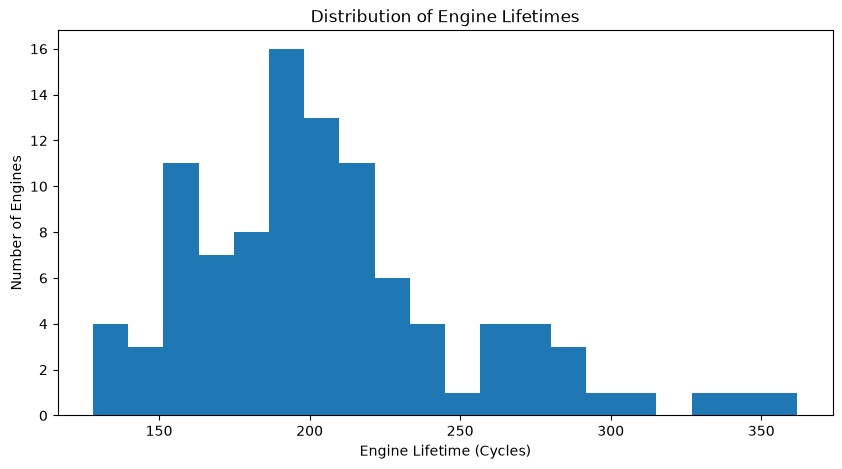

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    engine_lifetimes["max_cycle"],
    bins=20
)

plt.xlabel("Engine Lifetime (Cycles)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")

plt.show()

#### Distribution of Engine Lifetimes

The engine-lifetime distribution is concentrated mainly around
approximately 170–230 cycles.

However, lifetimes vary substantially across engines, with some
trajectories extending beyond 300 cycles and the maximum observed
lifetime reaching 362 cycles.

The distribution therefore shows noticeable variation and a
right-side tail.

Engine populations do not exhibit a single uniform lifetime.
This supports constructing RUL separately for each engine rather
than using a global lifetime value.

Further investigation is required before deciding how the RUL target
should be formulated.

In [15]:
train_df["max_cycle"] = (
    train_df.groupby("unit")["cycle"]
    .transform("max")
)

train_df["RUL_raw"] = (
    train_df["max_cycle"] - train_df["cycle"]
)

In [16]:
train_df[
    ["unit", "cycle", "max_cycle", "RUL_raw"]
].head(20)

,unit,cycle,max_cycle,RUL_raw
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


## Raw RUL Construction

For each training observation:

RUL_raw = engine maximum cycle − current cycle

This creates an engine-specific target.

For example, if an engine reaches its final observed cycle at 192,
then an observation at cycle 1 has a raw RUL of 191, while an
observation at cycle 192 has a raw RUL of 0.

The calculation is performed separately for every engine.

In [17]:
final_cycles = (
    train_df.sort_values(["unit", "cycle"])
    .groupby("unit")
    .tail(1)
)

final_cycles["RUL_raw"].describe()

count    100.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: RUL_raw, dtype: float64

In [18]:
(final_cycles["RUL_raw"] == 0).all()

np.True_

#### Raw RUL Sanity Check


The final observed cycle of every training engine has a raw RUL of 0.

The validation check:

(final_cycles["RUL_raw"] == 0).all()

returns True.

The raw RUL construction is internally consistent with the observed
training trajectories and passes the basic target sanity check.

In [19]:
train_df["RUL_raw"].describe()

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL_raw, dtype: float64

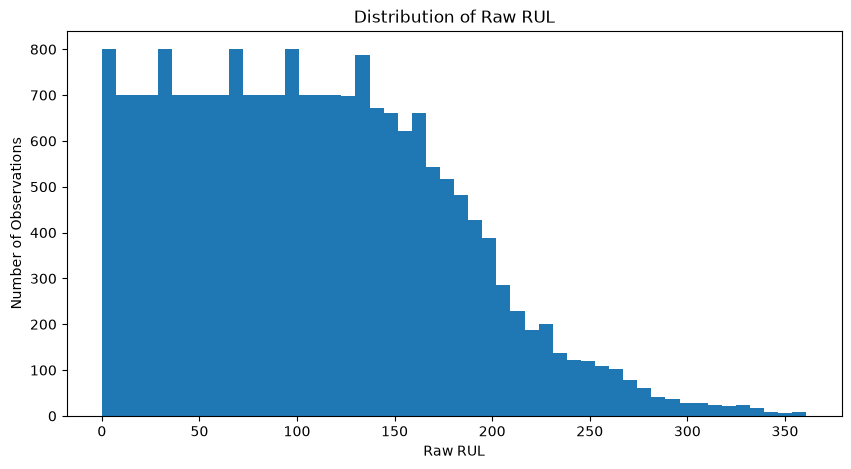

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["RUL_raw"],
    bins=50
)

plt.xlabel("Raw RUL")
plt.ylabel("Number of Observations")
plt.title("Distribution of Raw RUL")

plt.show()

#### Raw RUL Distribution

The raw RUL target ranges from 0 to 361 cycles.

Summary statistics:

- Mean: 107.81 cycles
- Median: 103 cycles
- Standard deviation: 68.88 cycles
- 25th percentile: 51 cycles
- 75th percentile: 155 cycles
- Maximum: 361 cycles

The distribution contains a large number of observations with high
remaining life and progressively fewer observations at very high RUL.

Although raw RUL is mathematically correct, the question is whether
the sensor measurements contain enough degradation information to
distinguish accurately between very large RUL values.

This motivates investigating a capped RUL target.

In [21]:
selected_units = [1, 10, 27, 50, 80]

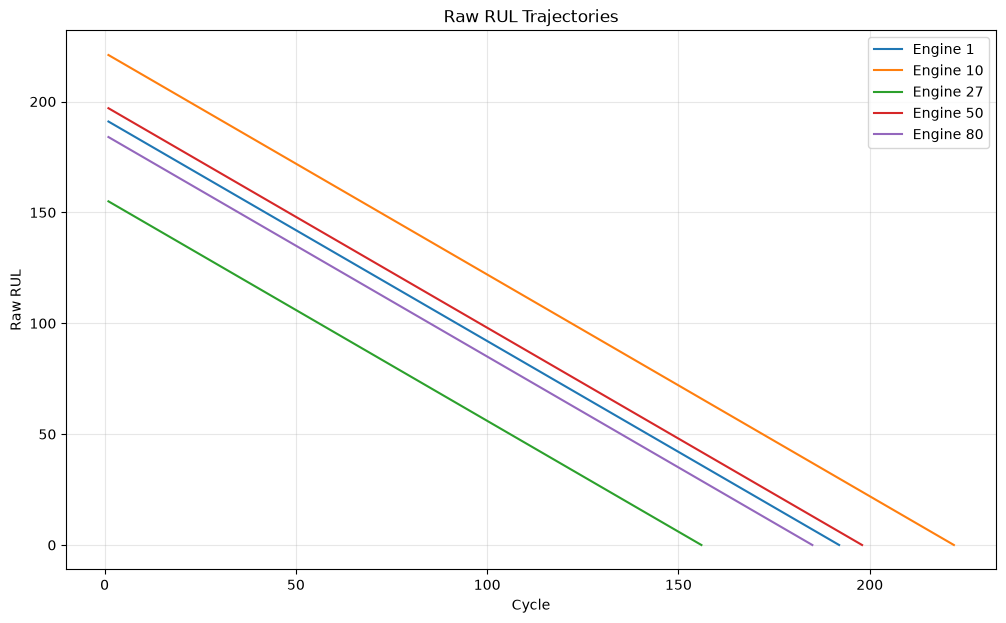

In [22]:
plt.figure(figsize=(12, 7))

for unit in selected_units:
    engine = train_df[train_df["unit"] == unit]
    
    plt.plot(
        engine["cycle"],
        engine["RUL_raw"],
        label=f"Engine {unit}"
    )

plt.xlabel("Cycle")
plt.ylabel("Raw RUL")
plt.title("Raw RUL Trajectories")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Raw RUL Trajectories

The selected engine trajectories show a linear decrease in raw RUL
with increasing cycle.

This linear behavior is expected because raw RUL is mathematically
defined as:

engine maximum cycle − current cycle

Therefore, each additional cycle reduces the target by exactly one.


These trajectories describe the constructed RUL target rather than
the physical degradation behavior of the sensors.

Sensor degradation will be investigated later during feature
engineering and exploratory analysis.

In [23]:
def add_capped_rul(df, cap):
    df = df.copy()
    df["RUL_capped"] = df["RUL_raw"].clip(upper=cap)
    return df

In [24]:
candidate_caps = [50, 75, 100, 125, 150]

In [25]:
for cap in candidate_caps:
    print(
        cap,
        (train_df["RUL_raw"] > cap).mean()
    )

50 0.7527991856914352
75 0.6316223159323349
100 0.5104454461732345
125 0.3892685764141341
150 0.27177548349571035


#### RUL Cap Selection


Candidate caps of 50, 75, 100, 125, and 150 cycles were evaluated
by measuring the proportion of observations affected by each cap.

The resulting proportions were:

- 50 cycles → 75.28%
- 75 cycles → 63.16%
- 100 cycles → 51.04%
- 125 cycles → 38.93%
- 150 cycles → 27.18%

A working RUL cap of 125 cycles is selected for the subsequent
modeling pipeline.

A cap of 125 substantially reduces the extreme upper range of the
target while retaining a majority of observations below the cap.

This is an engineering decision for the current modeling pipeline,
not a claim that 125 is universally optimal. Its usefulness should
ultimately be evaluated through validation performance.

In [26]:
cap = 125

train_df["RUL_capped"] = train_df["RUL_raw"].clip(upper=cap)

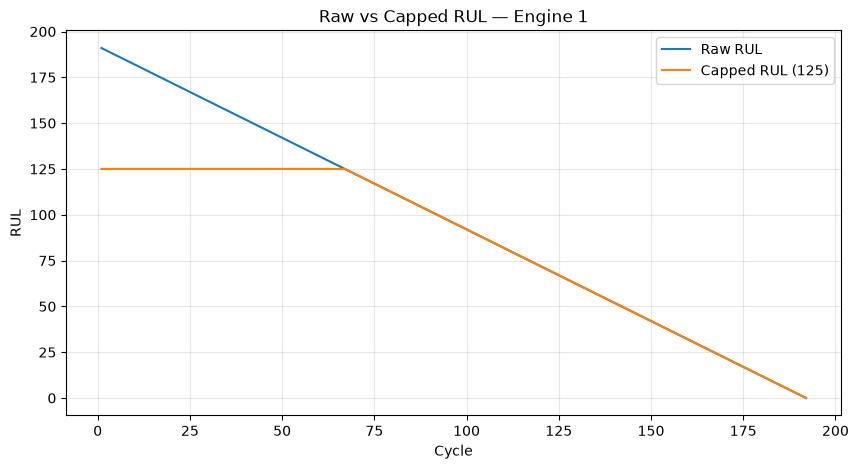

In [27]:
unit = 1

engine = train_df[train_df["unit"] == unit]

plt.figure(figsize=(10, 5))

plt.plot(
    engine["cycle"],
    engine["RUL_raw"],
    label="Raw RUL"
)

plt.plot(
    engine["cycle"],
    engine["RUL_capped"],
    label=f"Capped RUL ({cap})"
)

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title(f"Raw vs Capped RUL — Engine {unit}")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Raw vs Capped RUL


For Engine 1, raw RUL begins above the selected cap of 125 cycles.

The capped target therefore remains fixed at 125 during the early
portion of the trajectory.

Once raw RUL falls below 125, the capped and raw targets become
identical and both decrease toward zero.


Capping creates a piecewise-linear target:

- Healthy/early-life region → RUL = 125
- Degradation region → RUL decreases according to raw RUL

This reduces the need for the model to distinguish between very large
RUL values during the early-life region.

In [28]:
RUL_CAP = 125

train_df["RUL"] = train_df["RUL_raw"].clip(upper=RUL_CAP)

train_df[["unit", "cycle", "RUL_raw", "RUL"]].head(20)

,unit,cycle,RUL_raw,RUL
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


In [30]:
train_df[["RUL_raw", "RUL"]].describe()

,RUL_raw,RUL
count,20631.000000,20631.000000
mean,107.807862,86.829286
std,68.880990,41.673699
min,0.000000,0.000000
25%,51.000000,51.000000
50%,103.000000,103.000000
75%,155.000000,125.000000
max,361.000000,125.000000


In [31]:
print("Cap:", RUL_CAP)

print(
    "Percentage capped:",
    (train_df["RUL_raw"] > RUL_CAP).mean() * 100
)

Cap: 125
Percentage capped: 38.926857641413406


In [32]:
print("Minimum RUL:", train_df["RUL"].min())
print("Maximum RUL:", train_df["RUL"].max())
print("Number of zero-RUL observations:", (train_df["RUL"] == 0).sum())

Minimum RUL: 0
Maximum RUL: 125
Number of zero-RUL observations: 100


#### Capped RUL Sanity Check

The capped target satisfies the expected boundaries:

- Minimum RUL: 0
- Maximum RUL: 125
- Zero-RUL observations: 100

The 100 zero-RUL observations correspond to the final observed
cycle of each of the 100 training engines.

Therefore, capping changes only the upper portion of the target and
does not alter the failure-point labels.

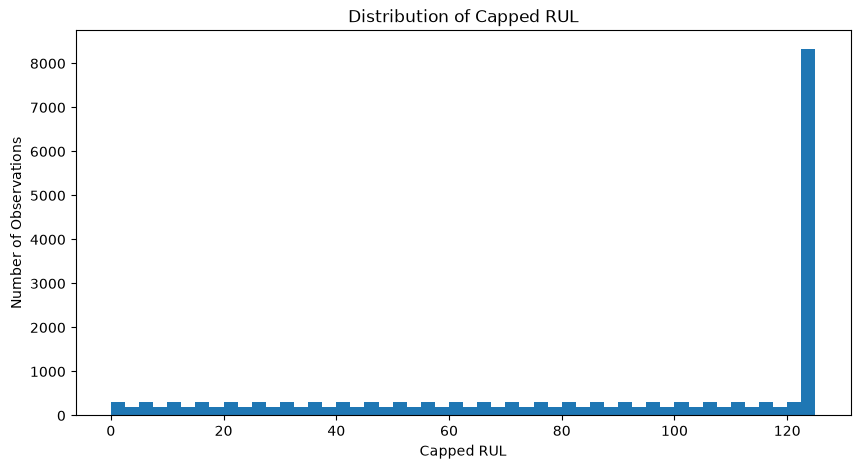

In [33]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["RUL"],
    bins=50
)

plt.xlabel("Capped RUL")
plt.ylabel("Number of Observations")
plt.title("Distribution of Capped RUL")

plt.show()

#### Capped RUL Distribution

After applying the 125-cycle cap, a large concentration of observations
appears at RUL = 125.

Approximately 38.93% of training observations are affected by the cap.

This concentration is expected because all raw RUL values above 125
are mapped to the same target value.

The capped target reduces the influence of extreme RUL values, but it
also creates a large concentration at the upper boundary.

Therefore, later model evaluation should examine whether predictions
capture the degradation region effectively rather than simply
predicting the upper cap.

In [34]:
test_engine_lifetimes = (
    test_df.groupby("unit")["cycle"]
    .max()
    .rename("test_max_cycle")
    .reset_index()
)

test_engine_lifetimes.head()

,unit,test_max_cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98


In [35]:
test_rul = rul_df.copy()

test_rul["unit"] = range(1, len(test_rul) + 1)

In [36]:
test_engine_lifetimes = test_engine_lifetimes.merge(
    test_rul,
    on="unit",
    how="left"
)

In [38]:
test_engine_lifetimes.head(10)

,unit,test_max_cycle,RUL_x,RUL_y
0,1,31,112,112
1,2,49,98,98
2,3,126,69,69
3,4,106,82,82
4,5,98,91,91
5,6,105,93,93
6,7,160,91,91
7,8,166,95,95
8,9,55,111,111
9,10,192,96,96


In [43]:
test_df = test_df.merge(
    test_engine_lifetimes[["unit", "test_max_cycle", "RUL_x" , "RUL_y"]],
    on="unit",
    how="left"
)

In [44]:
test_rul_map = (
    test_rul
    .set_index("unit")["RUL"]
)

test_df["provided_RUL"] = test_df["unit"].map(test_rul_map)

test_df["test_max_cycle"] = (
    test_df.groupby("unit")["cycle"]
    .transform("max")
)

test_df["RUL_raw"] = (
    test_df["test_max_cycle"]
    + test_df["provided_RUL"]
    - test_df["cycle"]
)

In [45]:
test_df["RUL"] = test_df["RUL_raw"].clip(upper=RUL_CAP)


In [46]:
test_df[
    ["unit", "cycle", "test_max_cycle",
     "provided_RUL", "RUL_raw", "RUL"]
].head(20)

,unit,cycle,test_max_cycle,provided_RUL,RUL_raw,RUL
0,1,1,31,112,142,125
1,1,2,31,112,141,125
2,1,3,31,112,140,125
3,1,4,31,112,139,125
4,1,5,31,112,138,125
5,1,6,31,112,137,125
6,1,7,31,112,136,125
7,1,8,31,112,135,125
8,1,9,31,112,134,125
9,1,10,31,112,133,125


In [47]:
last_test_cycles = (
    test_df.sort_values(["unit", "cycle"])
    .groupby("unit")
    .tail(1)
)

(
    last_test_cycles["RUL_raw"]
    .values
    ==
    last_test_cycles["provided_RUL"].values
).all()

np.True_

#### Test-Set RUL Construction

Unlike the training data, test trajectories end before the actual
failure point.

The provided RUL file gives the remaining life after the final
observed test cycle.

Therefore, the implied full engine lifetime is:

test_max_cycle + provided_RUL

and the RUL for each test observation is calculated as:

RUL_raw = test_max_cycle + provided_RUL − cycle

The same 125-cycle cap is then applied to maintain consistency with
the training target.

In [48]:
train_df["RUL"] = train_df["RUL_raw"].clip(upper=125)

In [49]:
test_df["RUL"] = test_df["RUL_raw"].clip(upper=125)

#### Consistent Target Definition

The same RUL cap of 125 cycles is applied to both training and test
targets.

This ensures that the target definition used during model development
is consistent with the target used for final evaluation.

In [50]:
print("TRAIN")
print(train_df[["RUL_raw", "RUL"]].describe())

print("\nTEST")
print(test_df[["RUL_raw", "RUL"]].describe())

TRAIN
            RUL_raw           RUL
count  20631.000000  20631.000000
mean     107.807862     86.829286
std       68.880990     41.673699
min        0.000000      0.000000
25%       51.000000     51.000000
50%      103.000000    103.000000
75%      155.000000    125.000000
max      361.000000    125.000000

TEST
            RUL_raw           RUL
count  13096.000000  13096.000000
mean     141.238470    108.919823
std       58.980114     27.580258
min        7.000000      7.000000
25%      102.000000    102.000000
50%      140.000000    125.000000
75%      179.000000    125.000000
max      340.000000    125.000000


In [51]:
print("Train maximum RUL:", train_df["RUL"].max())
print("Test maximum RUL:", test_df["RUL"].max())

Train maximum RUL: 125
Test maximum RUL: 125


#### **Validation Strategy**

RUL observations are generated from individual engine trajectories.

Because multiple observations belong to the same engine, randomly splitting rows could place observations from the same engine into both training and validation sets.

This would allow the model to learn engine-specific patterns and produce overly optimistic validation results.

Therefore, validation will be performed at the engine level using the `unit` identifier.

No engine will appear in both the training and validation partitions.

In [52]:
from sklearn.model_selection import GroupShuffleSplit

In [69]:
X = train_df.drop(columns=["RUL", "RUL_raw" , "max_cycle"])

y = train_df["RUL"]

groups = train_df["unit"]

In [70]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(X, y, groups=groups)
)

In [55]:
train_split = train_df.iloc[train_idx].copy()
val_split = train_df.iloc[val_idx].copy()

In [56]:
print("Training engines:", train_split["unit"].nunique())
print("Validation engines:", val_split["unit"].nunique())

Training engines: 80
Validation engines: 20


In [57]:
train_units = set(train_split["unit"])
val_units = set(val_split["unit"])

print("Overlapping engines:", train_units.intersection(val_units))

Overlapping engines: set()


#### Engine-Level Validation Strategy

Engine observations are not independent random samples.

Each engine contributes many consecutive observations, so randomly
splitting rows could place observations from the same engine in both
training and validation sets.

This would allow the model to learn engine-specific patterns and
produce overly optimistic validation performance.

GroupShuffleSplit is used with engine ID (`unit`) as the grouping
variable.

The resulting split contains:

- 80 training engines
- 20 validation engines
- 0 overlapping engines

### Validation

The intersection between training and validation engine IDs is empty.

Therefore, no engine appears in both subsets.

This provides an engine-level separation suitable for evaluating
generalization to unseen engines.

### **Key Findings**

#### Engine Lifetime

The FD001 training dataset contains 100 engines with substantially
different observed lifetimes.

Engine lifetime ranges from 128 to 362 cycles, with a mean of 206.31
cycles and a median of 199 cycles.

Therefore, RUL must be calculated separately for each engine.

#### Raw RUL

Raw RUL was constructed as:

RUL_raw = engine maximum cycle − current cycle

The resulting target ranges from 0 to 361 cycles.

The target passes the basic sanity check: the final observed cycle
of every training engine has RUL = 0.

#### RUL Capping

Candidate caps of 50, 75, 100, 125, and 150 cycles were investigated.

A cap of 125 cycles was selected as the working target cap because it
reduces the extreme upper range while retaining a substantial portion
of the original target variation.

Approximately 38.93% of training observations are capped at 125.

## 4. Final Training Target

The final training target is:

RUL = min(RUL_raw, 125)

The resulting target ranges from 0 to 125 cycles.

#### Test RUL

Test RUL was reconstructed using the provided final RUL values:

RUL_raw = test_max_cycle + provided_RUL − current_cycle

The calculation was verified by confirming that the RUL at the final
observed test cycle equals the provided RUL.

The same 125-cycle cap is applied to the test target.

#### Validation Strategy

An engine-level GroupShuffleSplit was used to prevent engine-level
leakage.

The split contains:

- 80 training engines
- 20 validation engines
- 0 overlapping engines

This ensures that validation measures performance on previously unseen
engines rather than previously seen engine trajectories.

#### Important Modeling Consideration

The capped target creates a large concentration of observations at
RUL = 125.

Later model evaluation should therefore examine both overall error
and the model's ability to predict the degradation region rather than
simply predicting the upper cap.